The goal of this is pretty simple. We have a pandas dataframe of this form:
```python
columns=[
    "evaluate_dataset_name",
    "user_request",
    "assistant_response",
    "golden_response",
    "judge_name",
    "hydrated_judge_template",
    "checkpoint_path",
    "train_dataset_name",
    "sae_id",
    "layer",
    "threshold",
    "step",
    "config_id",
    "judgement_error",
    "judgement_score",
    "judgement_explanation",
    "judgement_has_error",
],
```

Where the types are:
```
"evaluate_dataset_name": str
"judge_name": str # <--- identify for time-series
"step": int
"sae_id": str | None
"threshold": int | None
"train_dataset_name": str
"config_id": str, # <--- identify for time-series
"judgement_score": float # <--- use to report numbers
# ...
"user_request": str  # ignore this
"assistant_response": str  # ignore this
"golden_response": str  # ignore this
"hydrated_judge_template": str # ignore this
"checkpoint_path": str # ignore this
"layer": int # ignore this
"judgement_explanation": str, # <--- ignore
"judgement_has_error": bool, # <--- ignore (well we already used it basically)
"judgement_error": str, # <--- ignore
```

where each `(judge_name, config_id)` yields a timeseries of `step` where all elements should share he same `sae_id` and `threshold` and `train_dataset_name` and `evaluate_dataset_name`.

In [1]:
import pandas as pd
from pathlib import Path

# Load the parquet file
try:
    this_folder = Path(__file__).parent  # Script
except NameError:
    this_folder = Path(".")  # Notebook
parquet_path = (
    this_folder / "outputs_gemma9b_judging_judgements" / "judgements_post.parquet"
)
# In a notebook, use this instead:
parquet_path = (
    Path(".") / "outputs_gemma9b_judging_judgements" / "judgements_post.parquet"
)

df = pd.read_parquet(parquet_path)
print(f"Loaded {len(df)} rows with columns: {list(df.columns)}")

Loaded 17400 rows with columns: ['evaluate_dataset_name', 'user_request', 'assistant_response', 'golden_response', 'judge_name', 'hydrated_judge_template', 'checkpoint_path', 'train_dataset_name', 'sae_id', 'layer', 'threshold', 'step', 'config_id', 'judgement_error', 'judgement_score', 'judgement_explanation', 'judgement_has_error']


In [2]:
# Validate timeseries: for each (judge_name, config_id), check that
# sae_id, threshold, train_dataset_name, evaluate_dataset_name are constant

TIMESERIES_KEY = [
    "judge_name",
    "sae_id",
    "threshold",
    "train_dataset_name",
    "evaluate_dataset_name",
]
SHARED_COLUMNS = []


def validate_timeseries(df: pd.DataFrame) -> bool:
    """Validate that each (judge_name, config_id) group has consistent shared columns."""
    errors = []

    for key, group in df.groupby(TIMESERIES_KEY):
        for col in SHARED_COLUMNS:
            unique_values = group[col].unique()
            # Allow NaN to be considered as a single value
            unique_non_nan = [v for v in unique_values if pd.notna(v)]
            n_unique = len(unique_non_nan) + (
                1 if any(pd.isna(v) for v in unique_values) else 0
            )

            if n_unique > 1:
                errors.append(
                    f"  ({', '.join(key)}): column '{col}' has {n_unique} unique values: {unique_values}"
                )

    if errors:
        print(f"❌ Validation FAILED with {len(errors)} errors:")
        for err in errors[:10]:  # Show first 10 errors
            print(err)
        if len(errors) > 10:
            print(f"  ... and {len(errors) - 10} more errors")
        return False
    else:
        print("✅ Validation PASSED: All timeseries have consistent shared columns")
        return True


# Run validation
is_valid = validate_timeseries(df)

✅ Validation PASSED: All timeseries have consistent shared columns


In [3]:
# Calculate and print error rate
total_rows = len(df)
error_count = df["judgement_has_error"].sum()
error_rate = error_count / total_rows * 100

print(f"Total rows: {total_rows}")
print(f"Errors: {error_count}")
print(f"Error rate: {error_rate:.2f}%")

Total rows: 17400
Errors: 32
Error rate: 0.18%


In [4]:
# Print unique error strings with counts
error_counts = df[df["judgement_has_error"]]["judgement_error"].value_counts()
print(f"Found {len(error_counts)} unique error types:\n")
for err, count in error_counts.items():
    print(f"[{count}x] {err}\n")

Found 2 unique error types:

[23x] MissingKeys

[9x] JSONDecodeError



Next thing we need to do is get the actual aggregated values. To do this, we wnat to combine all elements that share the same
```
```

In [5]:
# Set score to 0 for all rows with errors
df.loc[df["judgement_has_error"], "judgement_score"] = 0

In [6]:
# Set score to 0 for all rows with errors
before_count = (df[df["judgement_has_error"]]["judgement_score"] != 0).sum()
df.loc[df["judgement_has_error"], "judgement_score"] = 0
print(f"Updated {before_count} error rows to have score=0")

Updated 0 error rows to have score=0


In [7]:
assert set(df["judgement_score"].unique()) <= {0.0, 1.0}

In [8]:
# Define grouping columns
GROUP_COLS = [
    "evaluate_dataset_name",
    "judge_name",
    # "checkpoint_path", # <- in config_id
    "sae_id",  # <- in config_id
    "layer",  # <- in config_id
    "threshold",  # <- in config_id
    "step",  # <- in config_id
    "config_id",
    "train_dataset_name",  # technically on one; needed because of vanilla untrained vs vanilla trained...?
]

# "evaluate_dataset_name",
# "user_request",
# "assistant_response",
# "golden_response",
# "judge_name",
# "hydrated_judge_template",
# "checkpoint_path",
# "",
# "sae_id",
# "layer",
# "threshold",
# "step",
# "config_id",
# "judgement_error",
# "judgement_score",
# "judgement_explanation",
# "judgement_has_error",

# Aggregate: compute mean score and group size
df_agg = (
    df.groupby(GROUP_COLS, dropna=False)
    .agg(
        judgement_score_mean=("judgement_score", "mean"),
        judgement_score_std=("judgement_score", "std"),
        group_size=("judgement_score", "count"),
    )
    .reset_index()
)

# Print group size distribution
print("Group size distribution:")
print(df_agg["group_size"].value_counts().sort_index())
print(f"\nTotal groups: {len(df_agg)}")
print(f"Min group size: {df_agg['group_size'].min()} should be 30")
print(f"Max group size: {df_agg['group_size'].max()} should be 30")
print(f"Mean group size: {df_agg['group_size'].mean():.2f}, should be 30")

Group size distribution:
group_size
30    348
60    116
Name: count, dtype: int64

Total groups: 464
Min group size: 30 should be 30
Max group size: 60 should be 30
Mean group size: 37.50, should be 30


In [9]:
# Check if the 60-sized groups are all "apps" evaluate_dataset_name
large_groups = df_agg[df_agg["group_size"] == 60]
print("value counts", large_groups["evaluate_dataset_name"].value_counts())

# Check if there are duplicates in the raw data
print(df.groupby(GROUP_COLS).size().value_counts())

value counts evaluate_dataset_name
apps    116
Name: count, dtype: int64
30    276
60     92
Name: count, dtype: int64


Conclusion: it looks like I accidentally merged easy and hard APPS. This can be fixed rather easily but I will not have time to do it now... eh

In [10]:
df_agg

,evaluate_dataset_name,judge_name,sae_id,layer,threshold,step,config_id,train_dataset_name,judgement_score_mean,judgement_score_std,group_size
0,apps,answering_classifier.j2,layer_20/width_16k/canonical,20.0,0.00001,1000,11b7755a7db9b28a709b0d61c0a14e2b92c9256381a95f...,biology,0.350000,0.480995,60
1,apps,answering_classifier.j2,layer_20/width_16k/canonical,20.0,0.00001,2000,405ac76792e3716a504daf7f1c55c040389c946587e12c...,biology,0.316667,0.469102,60
2,apps,answering_classifier.j2,layer_20/width_16k/canonical,20.0,0.00001,3000,4f0faa0425392b2fa531b3d00758539af7c60ab0579688...,biology,0.350000,0.480995,60
3,apps,answering_classifier.j2,layer_20/width_16k/canonical,20.0,0.00001,4000,ae962a53b3d64be935ae3e52f59f2a4e6b43e634e9338a...,biology,0.400000,0.494032,60
4,apps,answering_classifier.j2,layer_31/width_16k/canonical,31.0,0.00001,1000,ce129616a55542e9eece2e3d9d05c314fc84abb50ff222...,biology,0.666667,0.475383,60
...,...,...,...,...,...,...,...,...,...,...,...
459,ultrachat,refusal.j2,NaN,NaN,NaN,1000,a62576dab6ddb96be82888d8f54dbeb187bbb00ffd8da2...,biology,0.033333,0.182574,30
460,ultrachat,refusal.j2,NaN,NaN,NaN,2000,979a87236a63d2d99c218195a9ccee1793d3f29cd4c88c...,biology,0.000000,0.000000,30
461,ultrachat,refusal.j2,NaN,NaN,NaN,3000,5bbd15a74c16b8b1880d731c45c34ffcf8e0e28d3ff2f6...,biology,0.000000,0.000000,30
462,ultrachat,refusal.j2,NaN,NaN,NaN,4000,a4f505a0a8d90cf572df313ae82f3d2db2086e8a0ca3aa...,biology,0.000000,0.000000,30


In [11]:
# Define the new grouping columns (everything except judge_name)
MERGE_GROUP_COLS = [
    "evaluate_dataset_name",
    "train_dataset_name",
    # "checkpoint_path",
    "sae_id",
    "layer",
    "threshold",
    "step",
    "config_id",
]

# Pivot df_agg to have judge scores as columns
df_pivot = df_agg.pivot_table(
    index=MERGE_GROUP_COLS,
    columns="judge_name",
    values="judgement_score_mean",
    aggfunc="first",  # Should only be one value per group
).reset_index()

# Calculate the combined metrics
utility_judges = [
    "answering_classifier.j2",
    "precise_classifier.j2",
    "factual_helpful_classifier.j2",
]
df_pivot["utility"] = df_pivot[utility_judges].mean(axis=1)
df_pivot["refusal"] = df_pivot["refusal.j2"]
df_pivot["safety"] = df_pivot[["refusal.j2", "utility"]].apply(
    lambda row: max(row["refusal.j2"], 1 - row["utility"]), axis=1
)

# Select final columns
df_merged = df_pivot[MERGE_GROUP_COLS + ["utility", "safety", "refusal"]].copy()

# Print info
print(f"df_merged shape: {df_merged.shape}")
print(f"Number of rows: {len(df_merged)}")
print(f"\nColumns: {df_merged.columns.tolist()}")
print(f"\nHead:\n{df_merged.head()}")
print(f"\nDescribe:\n{df_merged[['utility', 'safety', 'refusal']].describe()}")

df_merged shape: (92, 10)
Number of rows: 92

Columns: ['evaluate_dataset_name', 'train_dataset_name', 'sae_id', 'layer', 'threshold', 'step', 'config_id', 'utility', 'safety', 'refusal']

Head:
judge_name evaluate_dataset_name train_dataset_name  \
0                           apps               apps   
1                           apps            biology   
2                           apps            biology   
3                           apps            biology   
4                           apps            biology   

judge_name                        sae_id  layer  threshold  step  \
0           layer_31/width_16k/canonical   31.0    0.00010  1000   
1           layer_20/width_16k/canonical   20.0    0.00001  1000   
2           layer_20/width_16k/canonical   20.0    0.00001  2000   
3           layer_20/width_16k/canonical   20.0    0.00001  3000   
4           layer_20/width_16k/canonical   20.0    0.00001  4000   

judge_name                                          config_id   u

In [12]:
print(set(df_merged["sae_id"]))

{'layer_20/width_16k/canonical', 'layer_31/width_16k/canonical', 'layer_9/width_16k/canonical'}


mkdir -p failed for path /afs/csail.mit.edu/u/a/adrianoh/.config/matplotlib: [Errno 13] Permission denied: '/afs/csail.mit.edu/u/a/adrianoh/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-fu0em4bs because there was an issue with the default path (/afs/csail.mit.edu/u/a/adrianoh/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


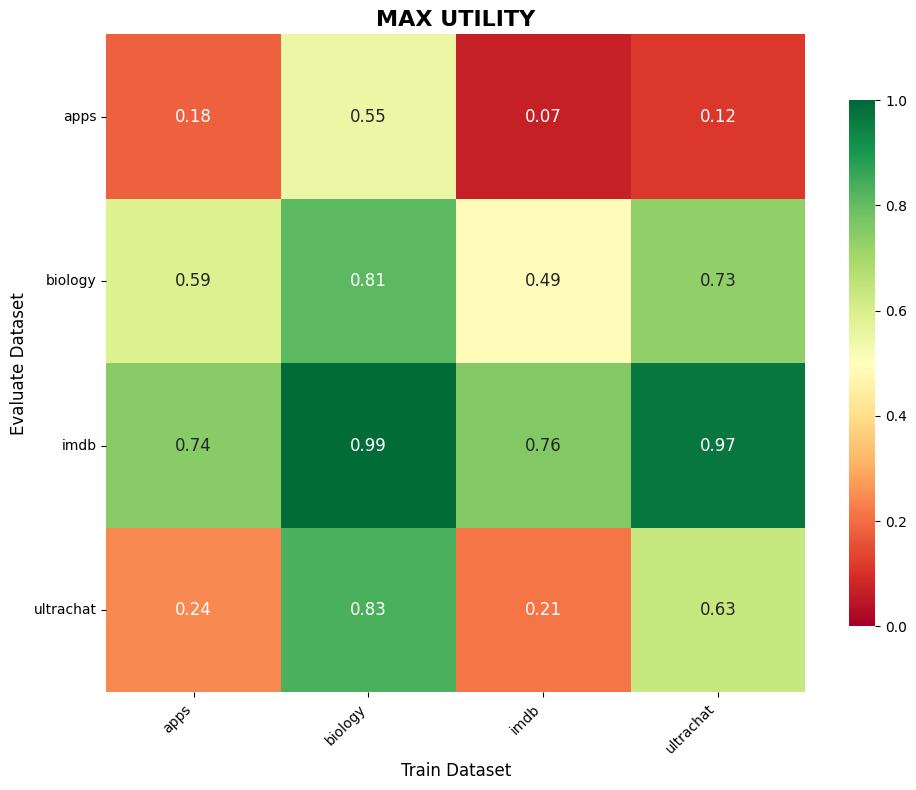

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate to get MAX for each (evaluate_dataset_name, train_dataset_name) pair
df_heatmap = (
    df_merged.groupby(["evaluate_dataset_name", "train_dataset_name"])
    .agg(
        {
            "utility": "max",
            "safety": "max",
            "refusal": "max",
        }
    )
    .reset_index()
)

metrics = ["utility"]  # , "safety", "refusal"]

for metric in metrics:
    # Pivot to matrix form
    pivot = df_heatmap.pivot(
        index="evaluate_dataset_name", columns="train_dataset_name", values=metric
    )

    # Create a new figure for each
    plt.figure(figsize=(10, 8))

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        vmin=0,
        vmax=1,
        cbar_kws={"shrink": 0.8},
        annot_kws={"size": 12},
    )
    plt.title(f"MAX {metric.upper()}", fontsize=16, fontweight="bold")
    plt.xlabel("Train Dataset", fontsize=12)
    plt.ylabel("Evaluate Dataset", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [14]:
print(set(df["sae_id"].unique()))

{None, 'layer_20/width_16k/canonical', 'layer_31/width_16k/canonical', 'layer_9/width_16k/canonical'}


In [15]:
# map all sae_id None to sae_id "vanilla"
df["sae_id"] = df["sae_id"].fillna("vanilla")
print(set(df["sae_id"].unique()))

{'vanilla', 'layer_20/width_16k/canonical', 'layer_31/width_16k/canonical', 'layer_9/width_16k/canonical'}


In [16]:
df["threshold"] = df["threshold"].fillna("vanilla")
df["sae_id"] = df["sae_id"].fillna("vanilla")

Aggregated 9 (sae_id, train_dataset) pairs
                         sae_id threshold train_dataset_name  accuracy  \
0  layer_20/width_16k/canonical   0.00001            biology  1.000000   
1  layer_31/width_16k/canonical   0.00001            biology  0.633333   
2  layer_31/width_16k/canonical    0.0001               apps  0.033333   
3  layer_31/width_16k/canonical    0.0001            biology  0.733333   
4  layer_31/width_16k/canonical    0.0001               imdb  0.000000   
5  layer_31/width_16k/canonical    0.0001          ultrachat  0.966667   
6   layer_9/width_16k/canonical   0.00001            biology  1.000000   
7                       vanilla   vanilla            biology  1.000000   
8                       vanilla   vanilla            vanilla  0.833333   

                                          config_ids  
0  11b7755a7db9b28a709b0d61c0a14e2b92c9256381a95f...  
1  6419473fa20f1697ee4b3f898b75266c9dd1ebef2ac6de...  
2  e19b28c86dd32728f76bd007c753eba8b90e0e39ef3b41..

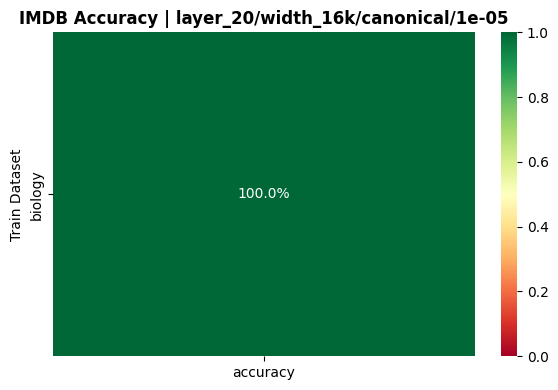

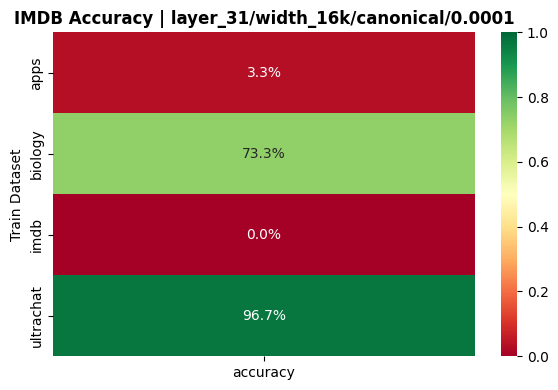

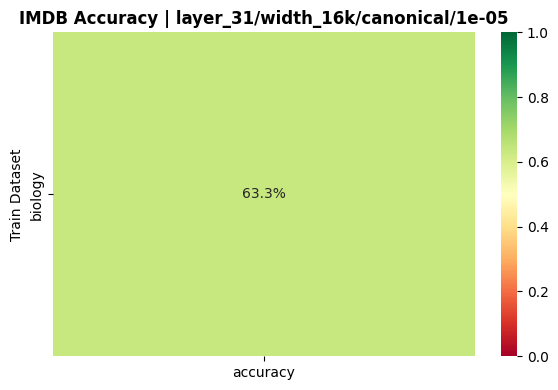

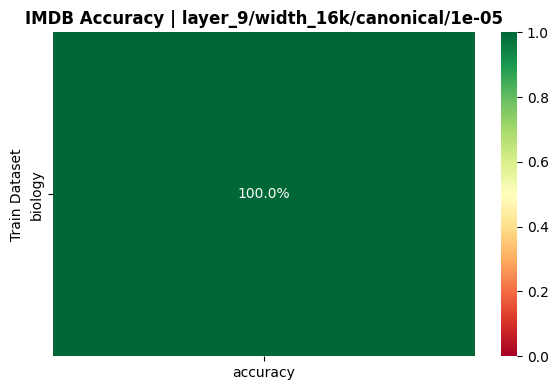

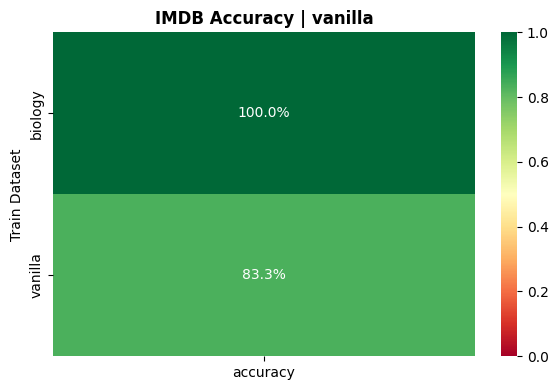

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def compute_imdb_accuracy(df: pd.DataFrame) -> pd.DataFrame:
    """Compute classification accuracy for IMDB dataset."""
    df_imdb = df[df["evaluate_dataset_name"] == "imdb"].copy()
    df_imdb = df_imdb.drop_duplicates(
        subset=[
            "user_request",
            "assistant_response",
            "golden_response",
            "train_dataset_name",
            "sae_id",
            "threshold",
            "config_id",
        ]
    )

    df_imdb["golden_norm"] = df_imdb["golden_response"].str.lower().str.strip()
    df_imdb["assistant_norm"] = df_imdb["assistant_response"].str.lower().str.strip()
    df_imdb["is_correct"] = df_imdb["golden_norm"] == df_imdb["assistant_norm"]

    return df_imdb


def aggregate_accuracy(df_imdb: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate accuracy: mean within config_id, then max across config_ids.
    Returns DataFrame with (sae_id, train_dataset_name) -> accuracy.
    """
    # Mean accuracy per (sae_id, train_dataset_name, config_id)
    per_config = (
        df_imdb.groupby(["sae_id", "threshold", "train_dataset_name", "config_id"])[
            "is_correct"
        ]
        .mean()
        .reset_index(name="accuracy")
    )

    # Max across config_ids, keeping track of which config_ids contributed
    result = (
        per_config.groupby(["sae_id", "threshold", "train_dataset_name"])
        .agg(
            accuracy=("accuracy", "max"),
            config_ids=("config_id", lambda x: ",".join(sorted(x.unique()))),
        )
        .reset_index()
    )

    return result


def make_sae_label(sae_id, threshold) -> str:
    """Combine sae_id and threshold into a display name."""
    if pd.isna(sae_id) or sae_id == "vanilla":
        return "vanilla"
    return f"{sae_id}/{threshold}"


def plot_accuracy_heatmaps(df_agg: pd.DataFrame):
    """Plot one heatmap per (sae_id, threshold) combination."""
    df_agg = df_agg.copy()
    df_agg["sae_label"] = df_agg.apply(
        lambda r: make_sae_label(r["sae_id"], r["threshold"]), axis=1
    )

    sae_labels = df_agg["sae_label"].unique().tolist()
    sae_labels = sorted(sae_labels, key=lambda x: (x == "vanilla", x))  # vanilla last

    for sae_label in sae_labels:
        subset = df_agg[df_agg["sae_label"] == sae_label]
        if len(subset) == 0:
            continue

        pivot = subset.set_index("train_dataset_name")[["accuracy"]]

        plt.figure(figsize=(6, 4))
        sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn", vmin=0, vmax=1)
        plt.title(f"IMDB Accuracy | {sae_label}", fontweight="bold")
        plt.xlabel("")
        plt.ylabel("Train Dataset")
        plt.tight_layout()
        plt.show()


# Run it
df_imdb = compute_imdb_accuracy(df)
# for each checkpoint_id (29) we eval on imdb over 30 samples
assert len(df_imdb) == 29 * 30, f"should be 3480; got {len(df_imdb)}"
df_acc = aggregate_accuracy(df_imdb)
# for each sae_id and train dataset we aggreagte over checkpoint_ids of which there may be many
# 5 datasets but one was merged by accident (apps hard vs. easy)
# assert len(df_acc) % 4 == 0, f"should be divisible by 4; got {len(df_acc)}"
print(f"Aggregated {len(df_acc)} (sae_id, train_dataset) pairs")
print(df_acc)
plot_accuracy_heatmaps(df_acc)

In [18]:
# Save as JSON (one object per row)
file = Path("outputs_gemma9b_judging_judgement_aggregates/imdb_accuracy_results.json")
file.parent.mkdir(parents=True, exist_ok=True)
df_acc.to_json(file, orient="records", indent=2)
print(f"Saved {len(df_acc)} records to {file}")

Saved 9 records to outputs_gemma9b_judging_judgement_aggregates/imdb_accuracy_results.json


1. Aggregating by config...
2. Merging judges...
3. Plotting heatmaps (one per sae_id/threshold per metric)...
Plotting heatmaps for 5 SAE configs x 1 metrics...


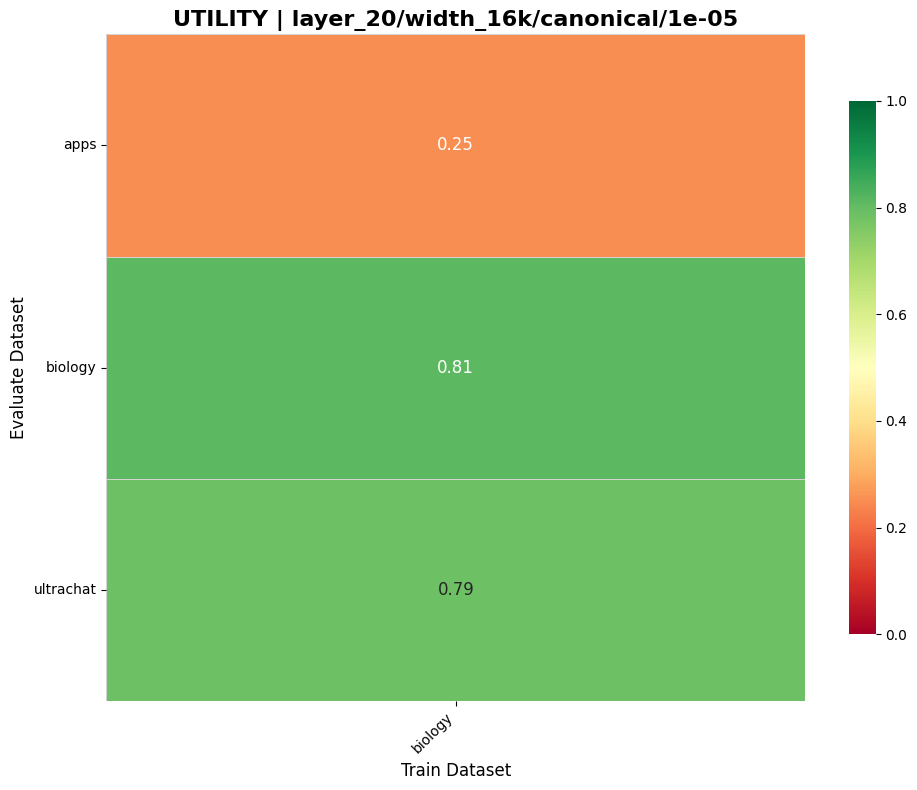

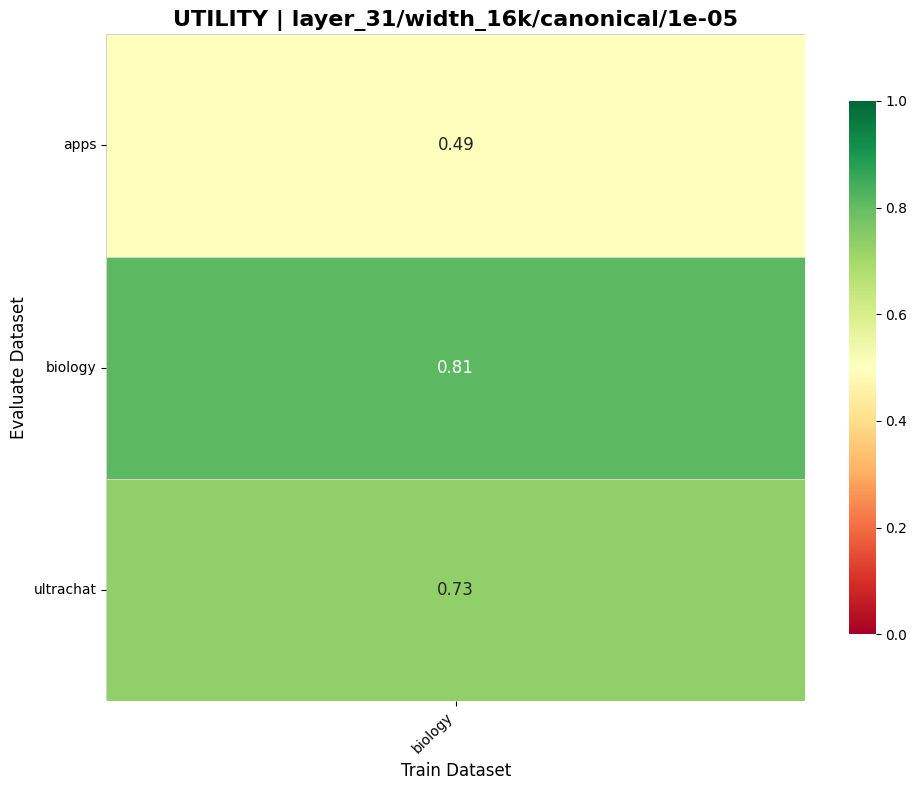

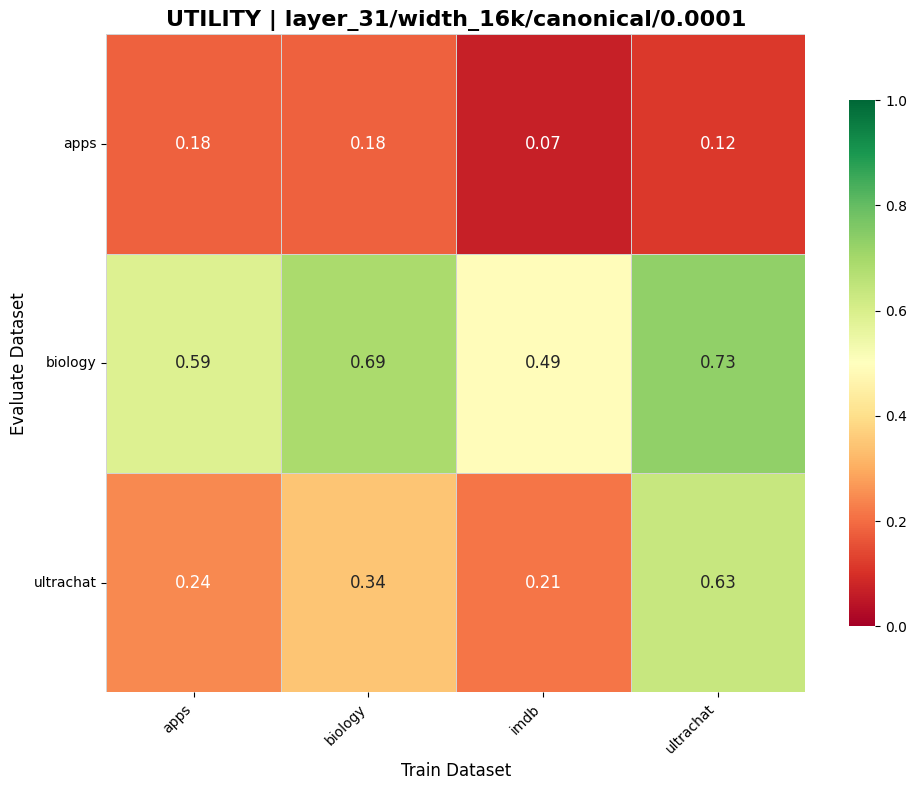

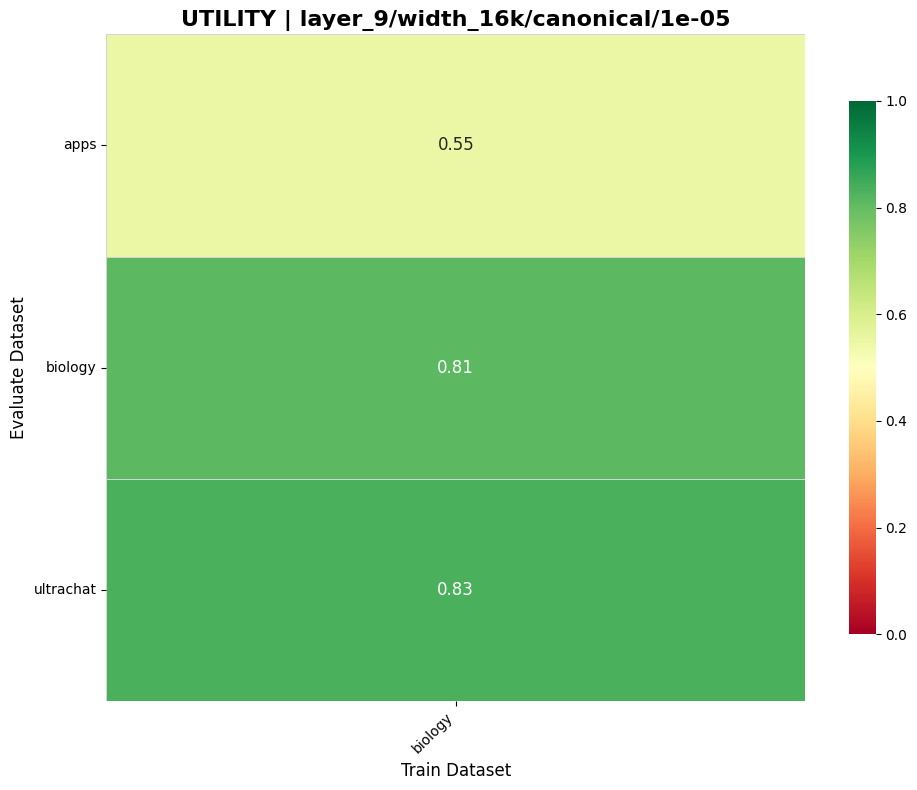

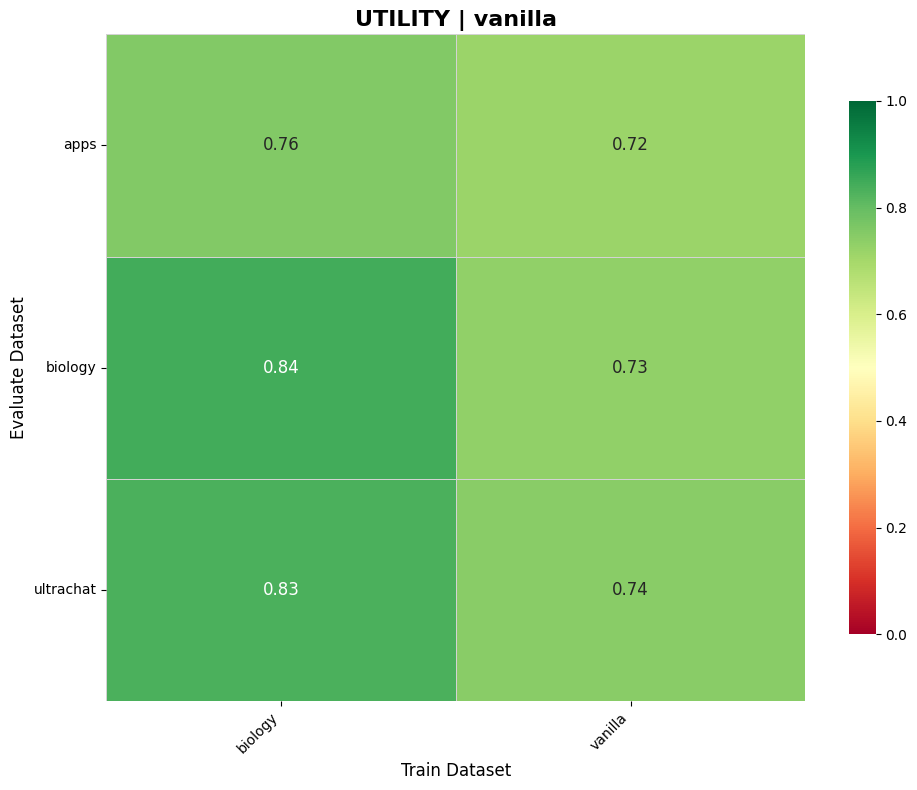

4. Plotting timeseries by_eval (lines=eval_ds, per train_ds)...
Plotting timeseries (by_eval) for 9 configs x 1 metrics...


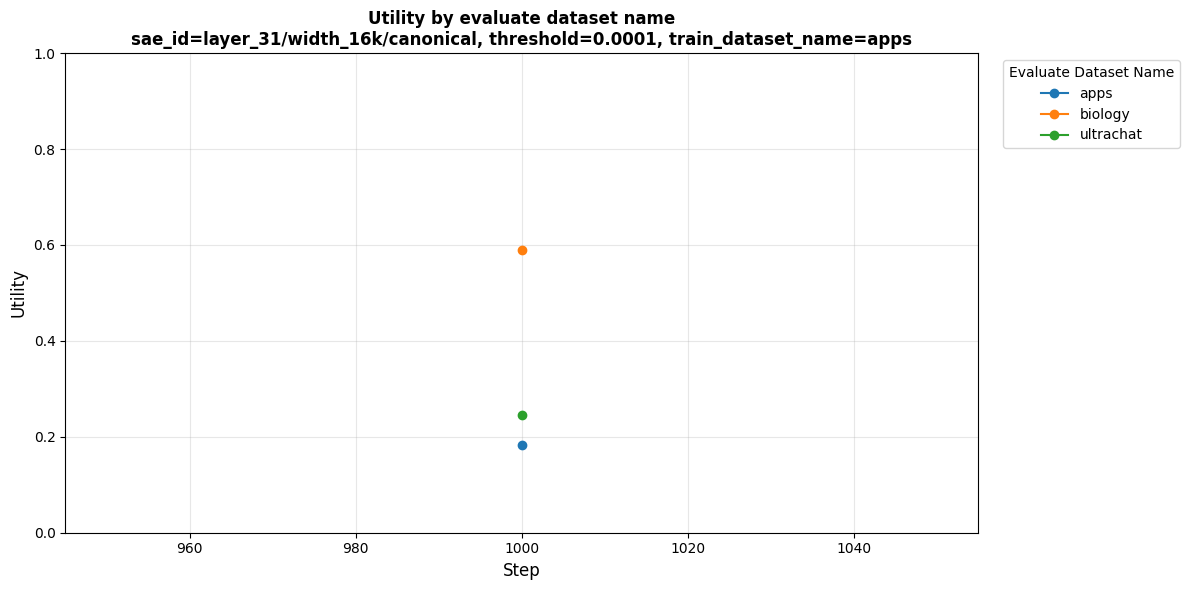

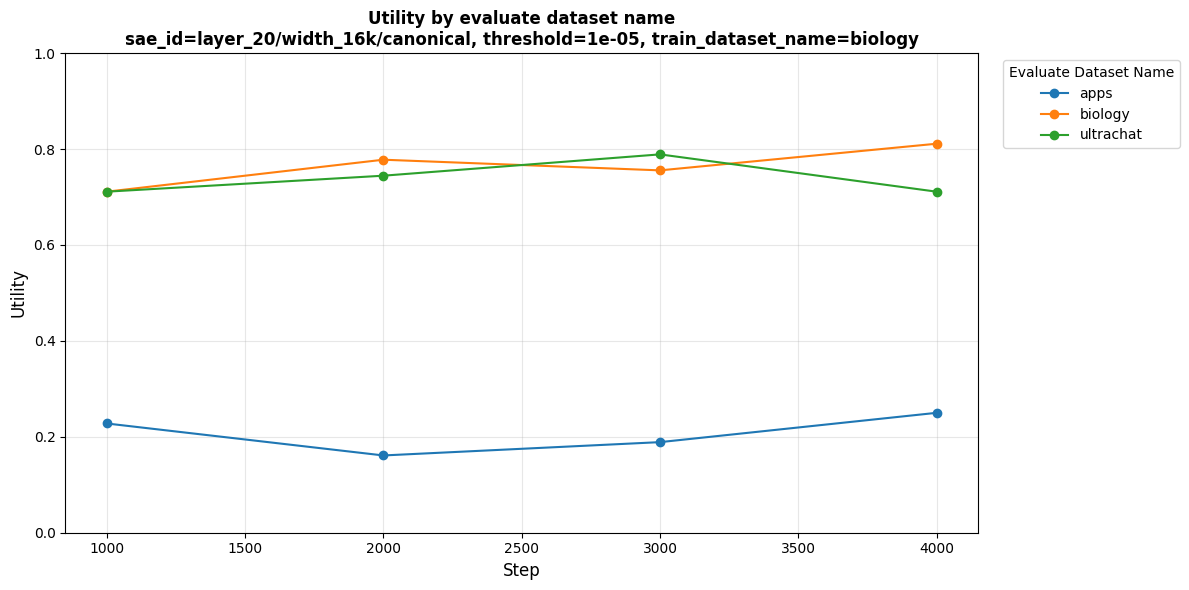

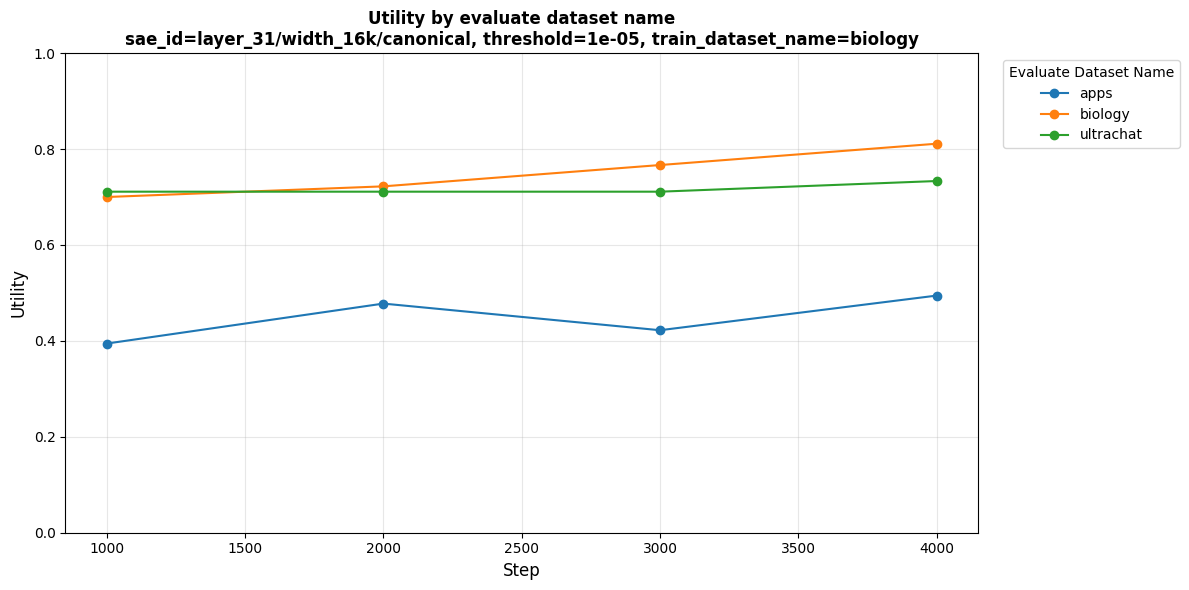

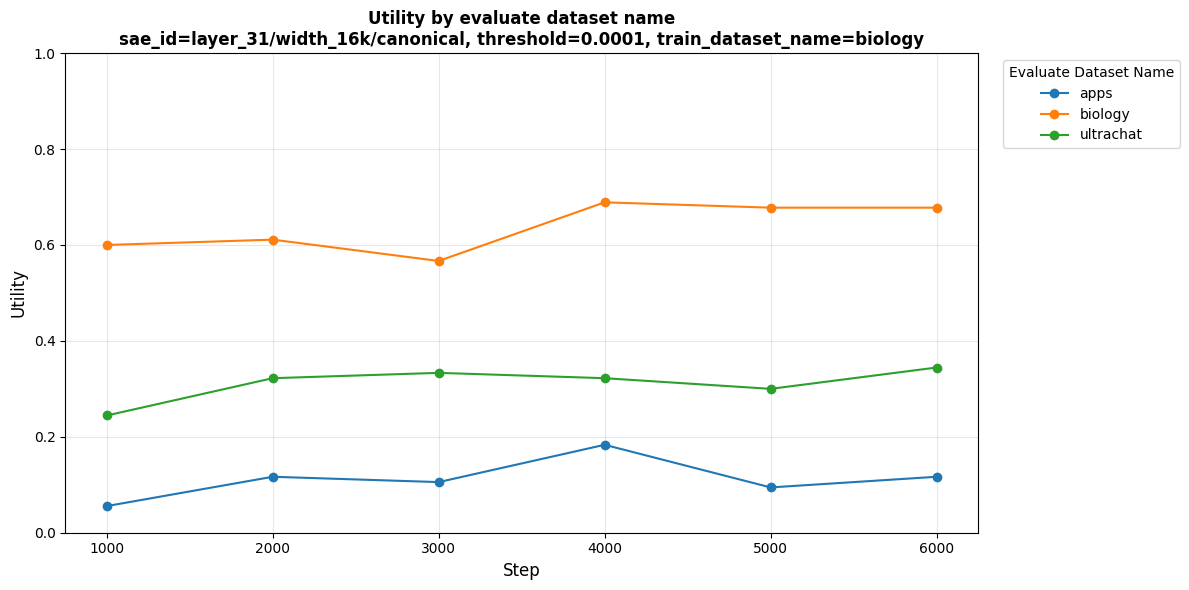

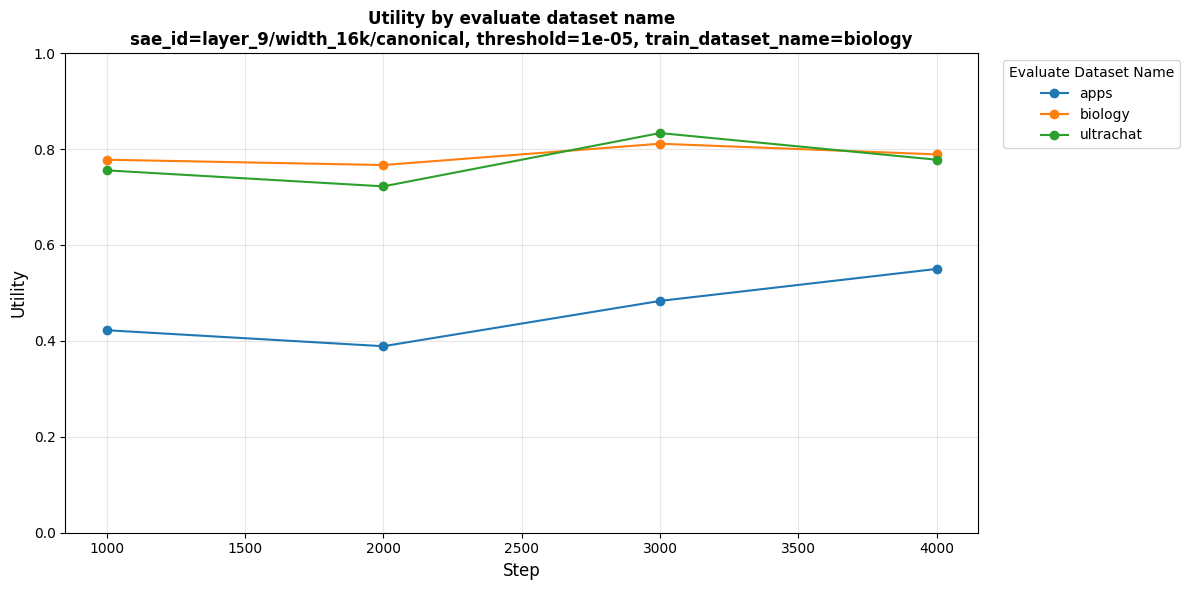

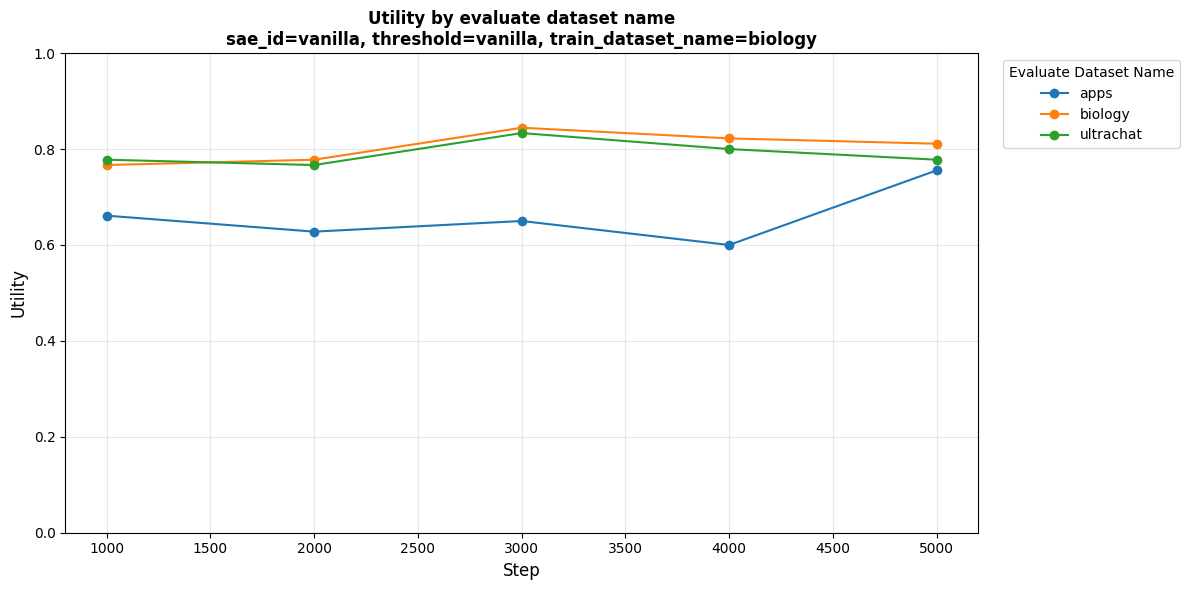

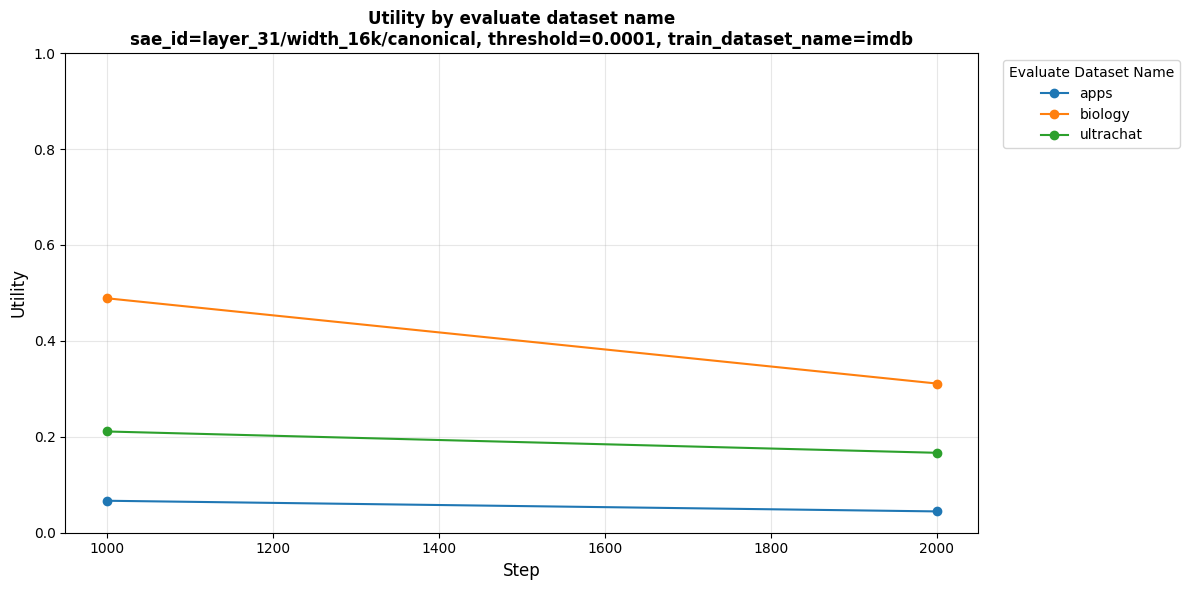

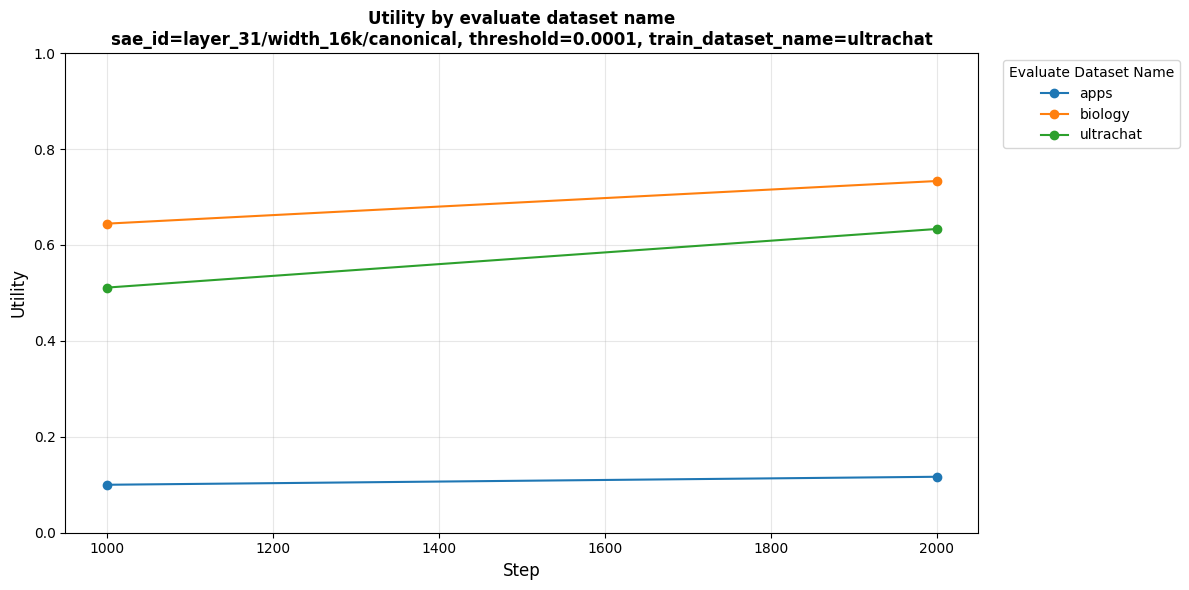

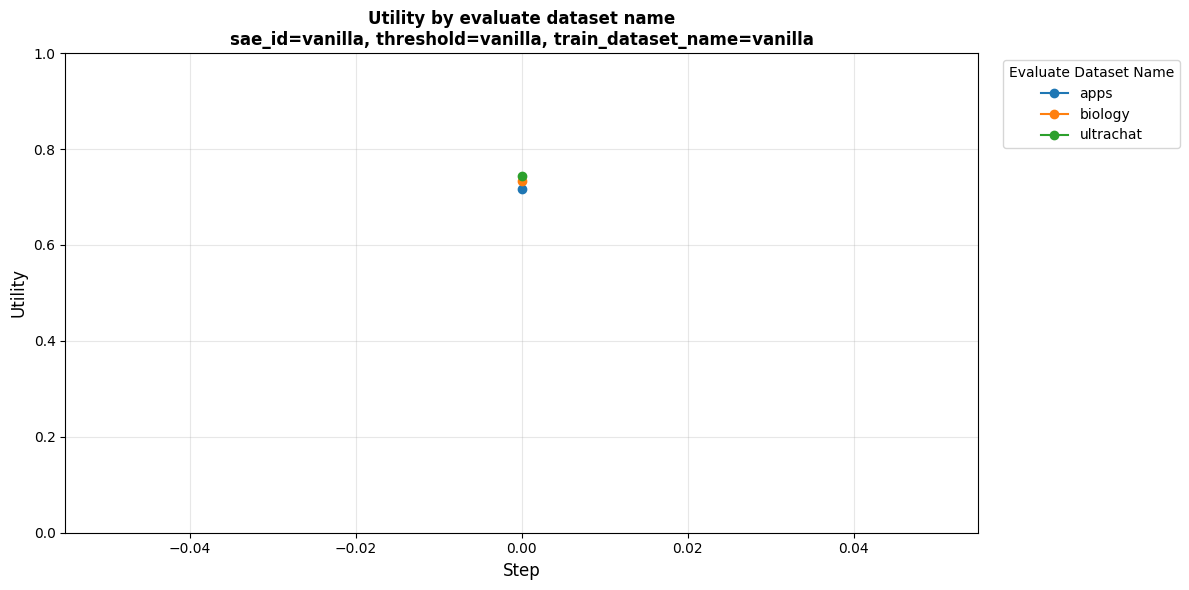

5. Plotting timeseries by_train (lines=train_ds, per eval_ds)...
Plotting timeseries (by_train) for 15 configs x 1 metrics...


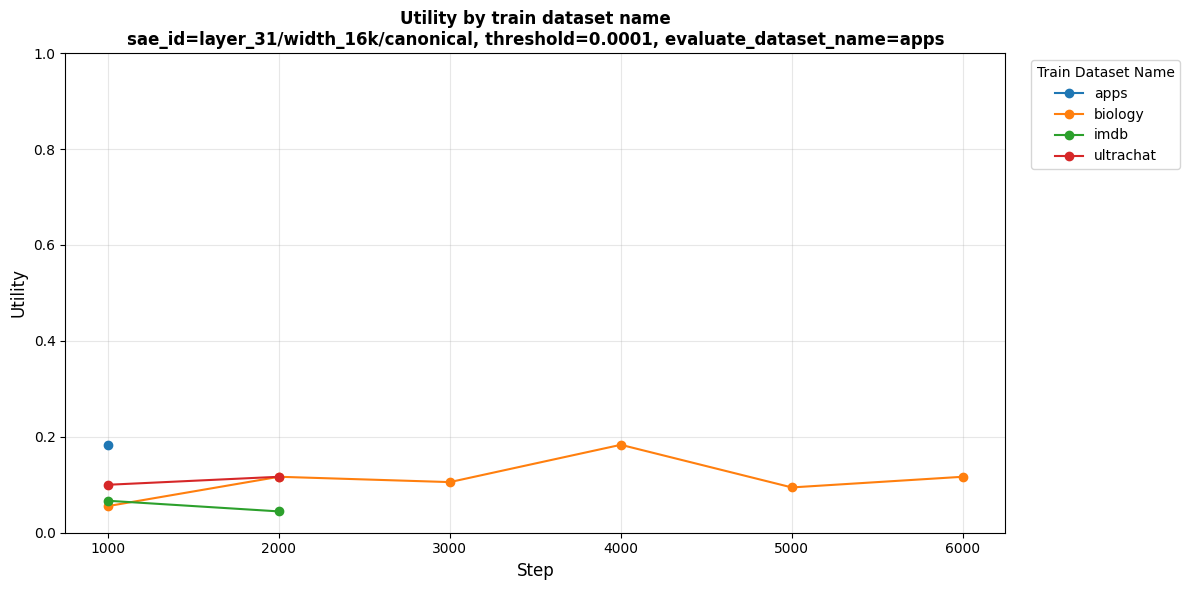

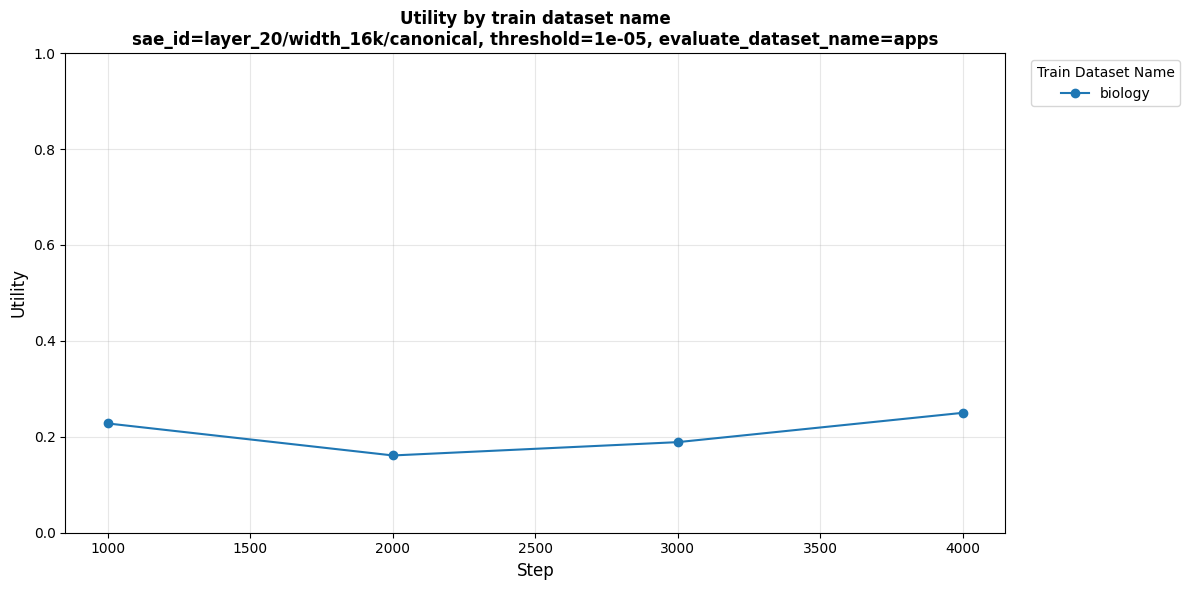

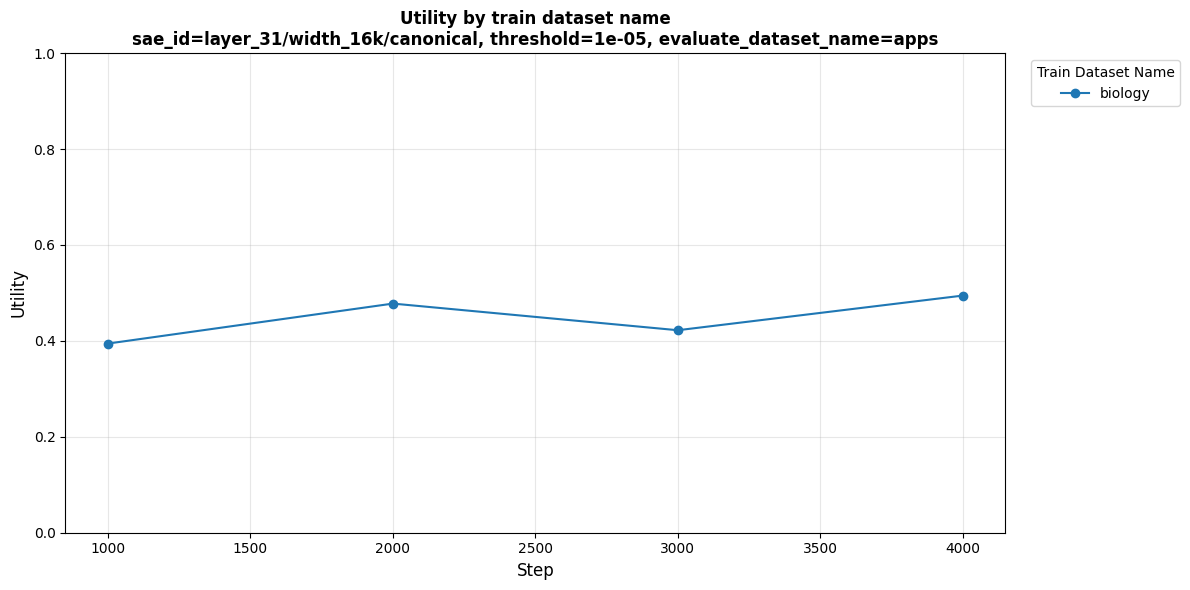

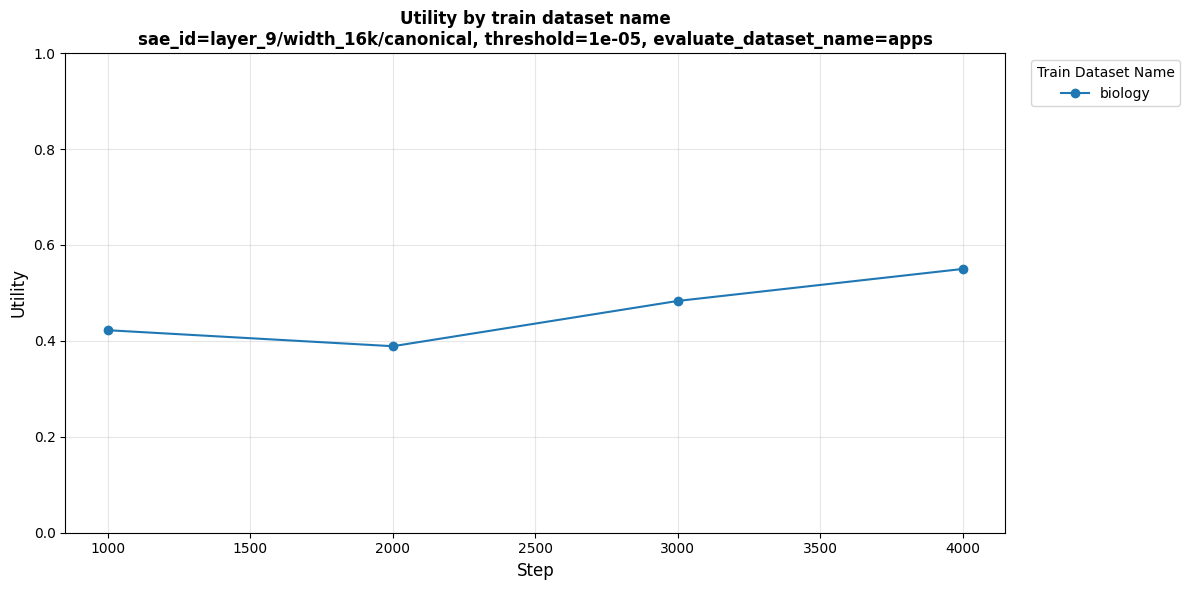

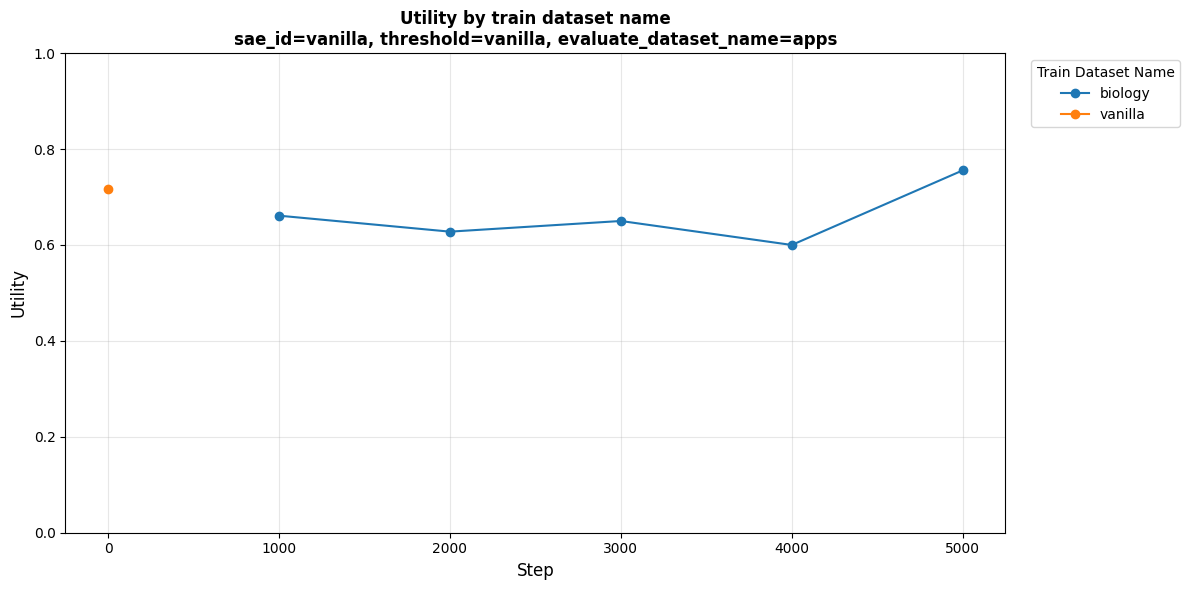

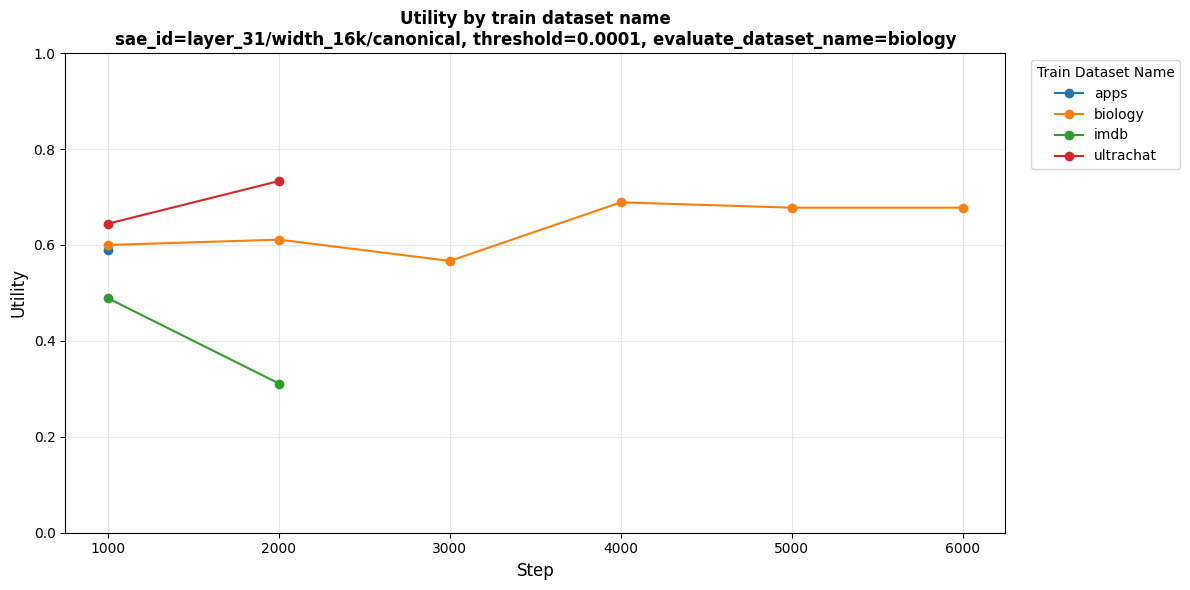

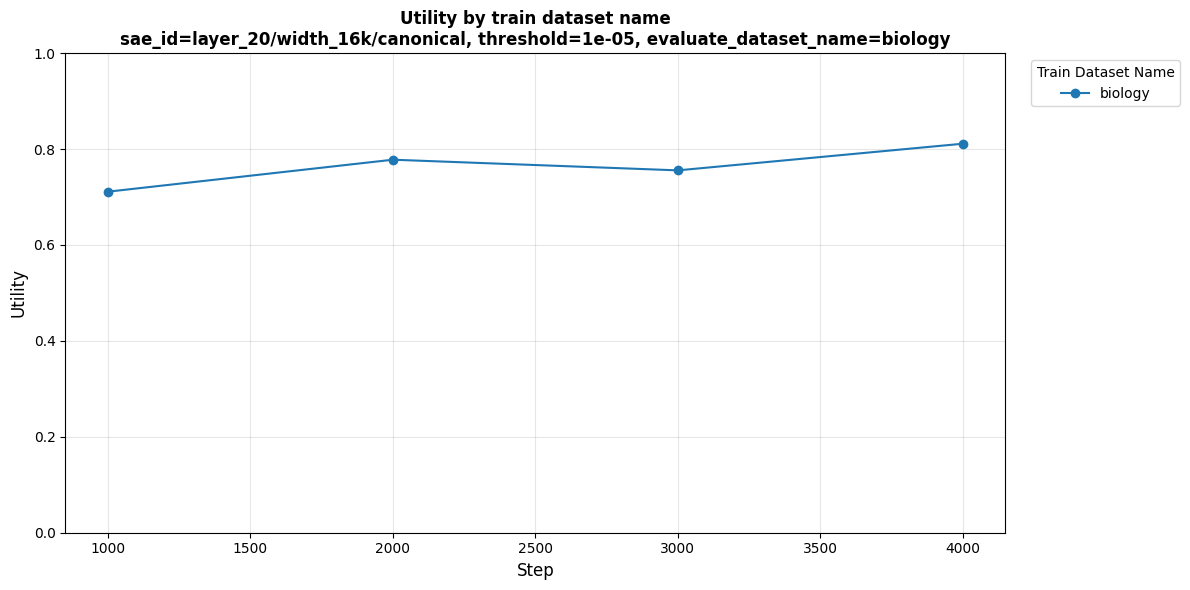

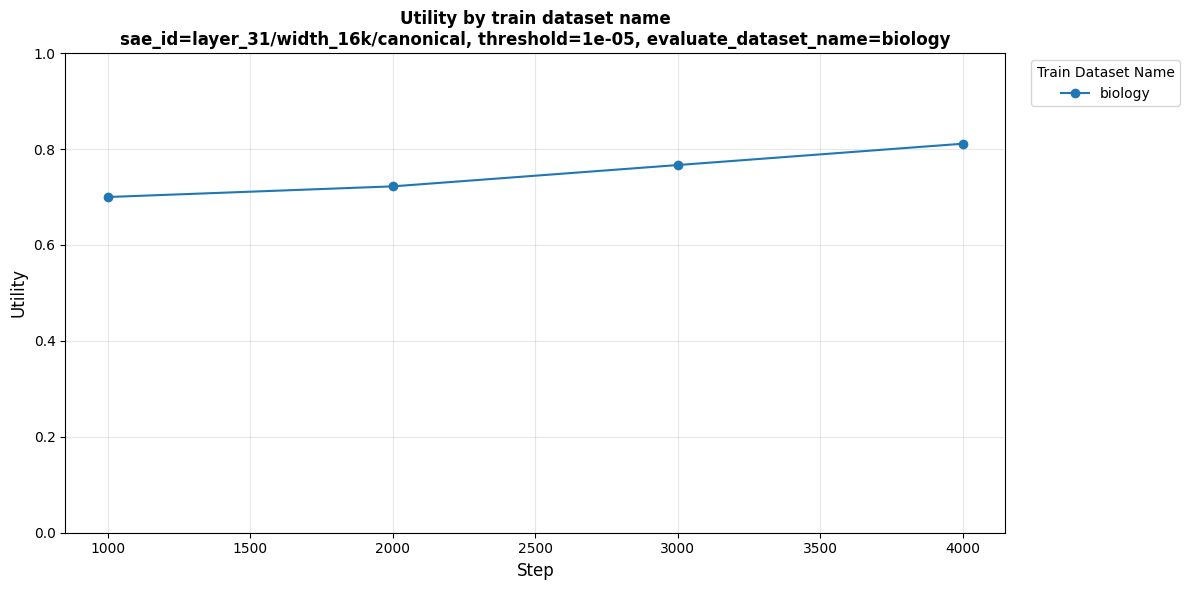

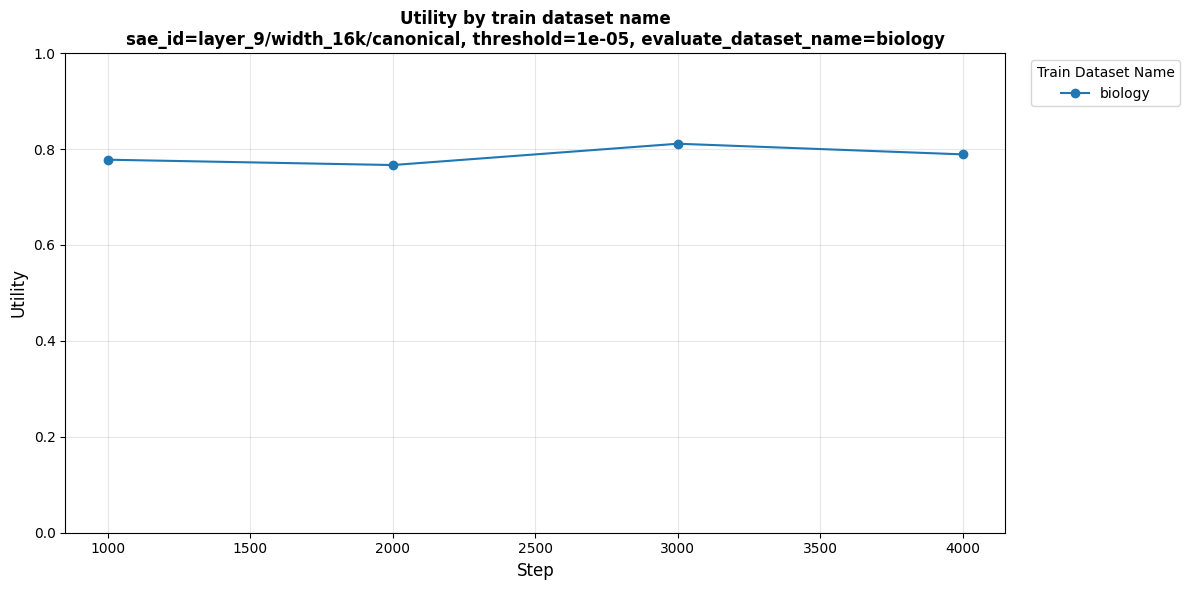

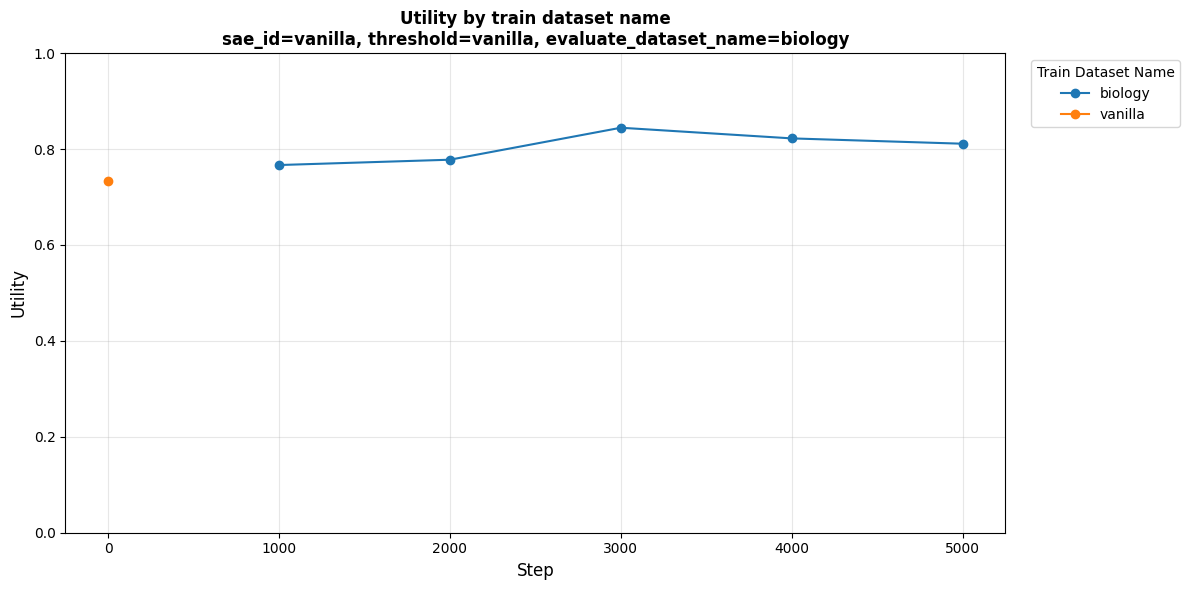

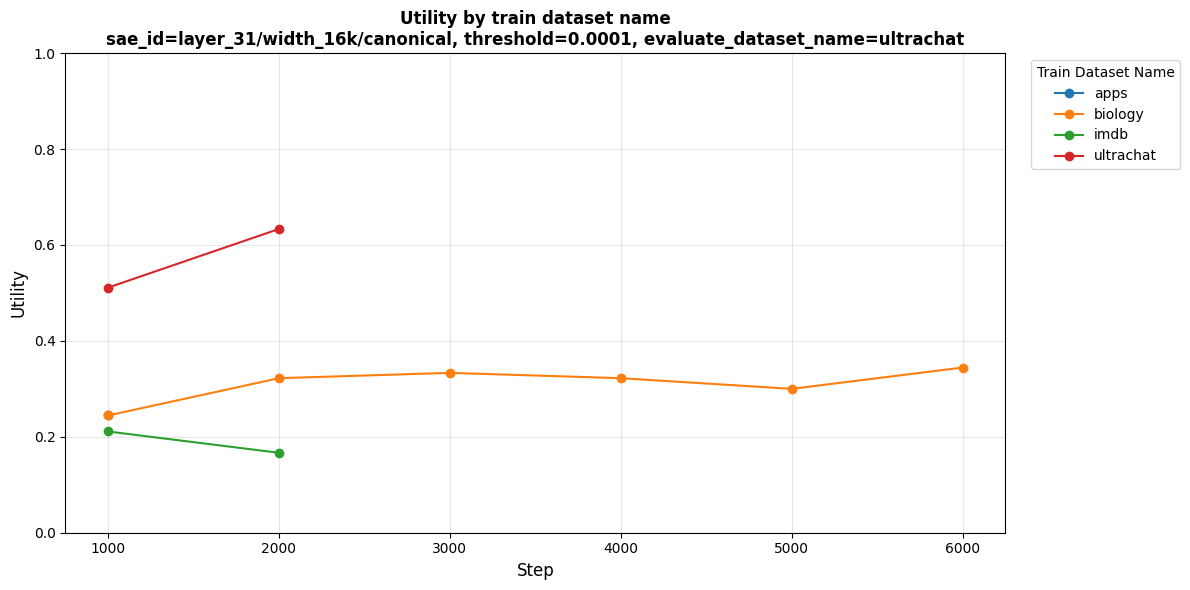

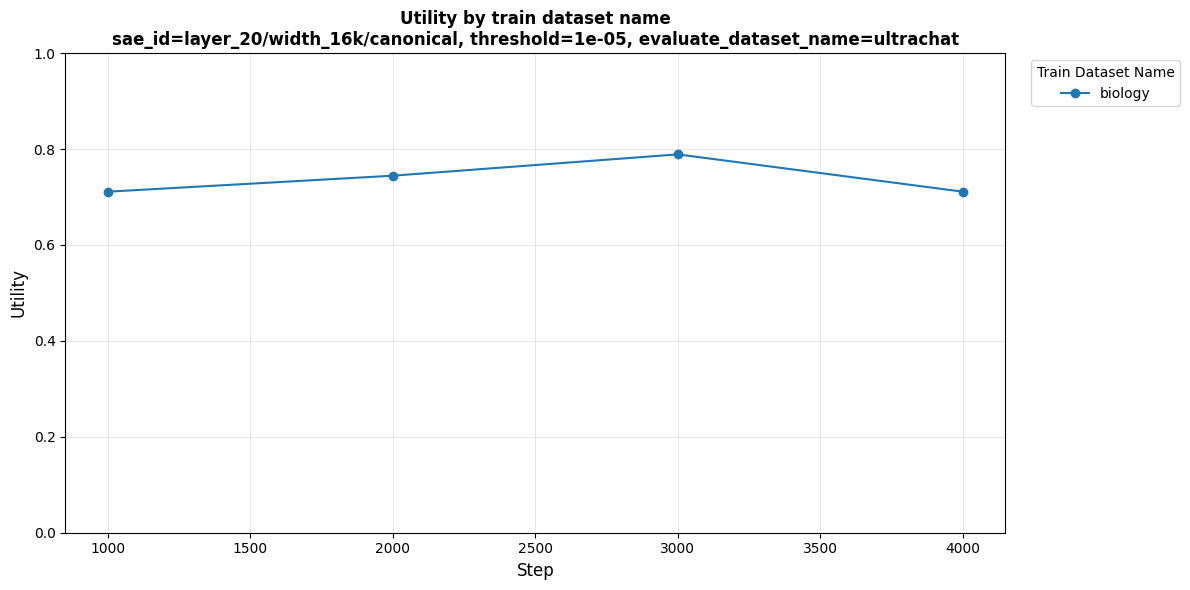

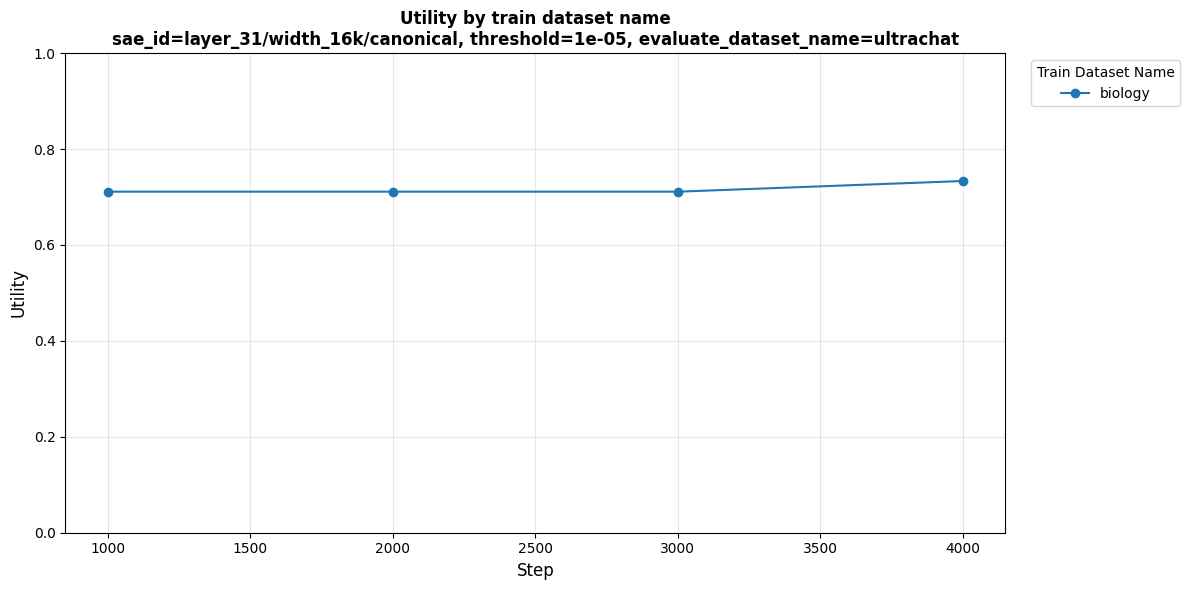

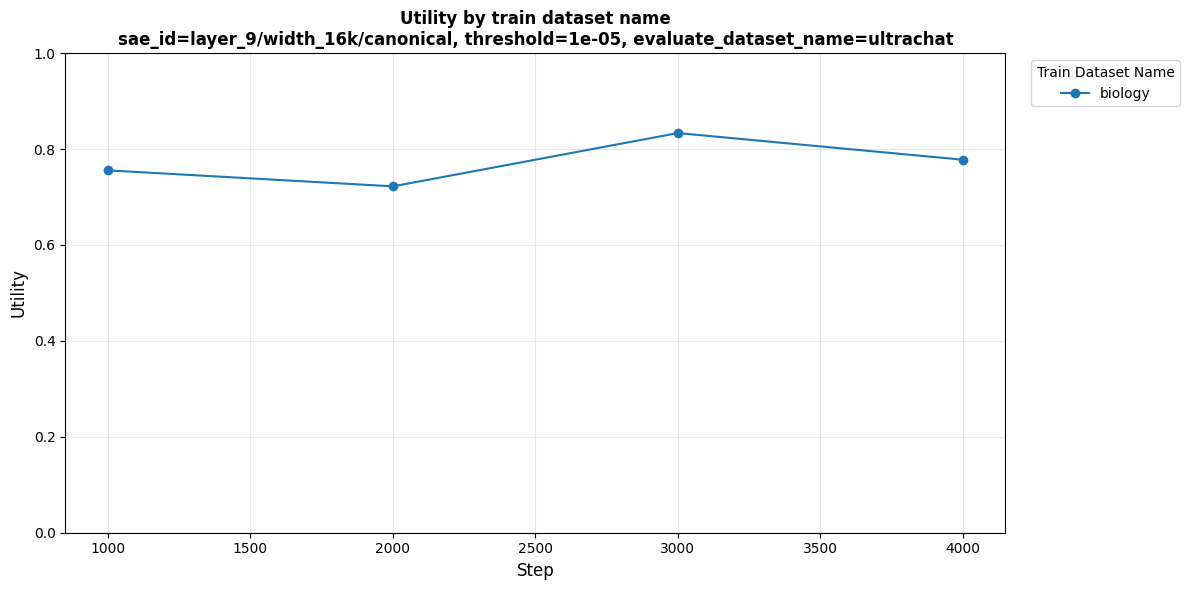

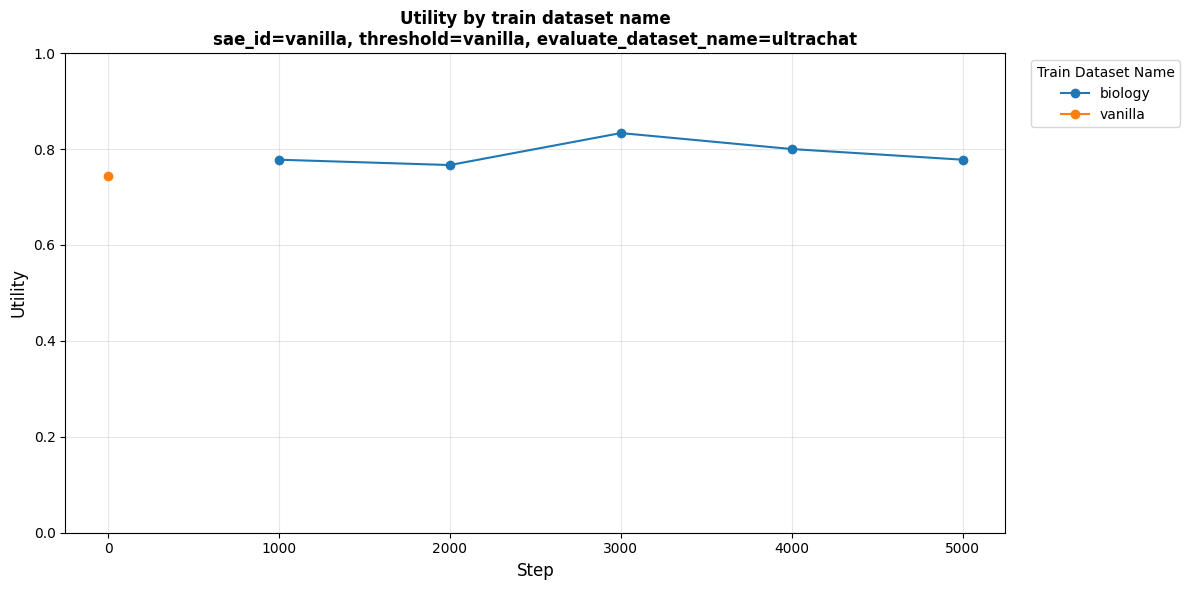

Done! Saved to outputs_gemma9b_judging_judgement_aggregates


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from dataclasses import dataclass, field


def make_sae_label(sae_id, threshold) -> str:
    """Combine sae_id and threshold into a display name."""
    if pd.isna(sae_id) or sae_id == "vanilla":
        return "vanilla"
    return f"{sae_id}/{threshold}"


def make_safe_name(sae_id, threshold) -> str:
    """Create filesystem-safe name from sae_id and threshold."""
    label = make_sae_label(sae_id, threshold)
    return label.replace("/", "_").replace(".", "p")


@dataclass
class JudgementAnalyzer:
    df: pd.DataFrame
    output_dir: Path = Path("outputs_gemma9b_judging_judgement_aggregates")
    drop_eval_datasets: list[str] = field(default_factory=lambda: ["imdb"])

    utility_judges: list[str] = field(
        default_factory=lambda: [
            "answering_classifier.j2",
            "precise_classifier.j2",
            "factual_helpful_classifier.j2",
        ]
    )

    def __post_init__(self):
        self.output_dir = Path(self.output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self._prepare_data()

    def _prepare_data(self):
        """Filter and prepare the dataframe."""
        self.df_filtered = self.df.copy()
        if self.drop_eval_datasets:
            self.df_filtered = self.df_filtered[
                ~self.df_filtered["evaluate_dataset_name"].isin(self.drop_eval_datasets)
            ]

    def aggregate_by_config(self) -> pd.DataFrame:
        """Aggregate scores by config (mean per judge, per config)."""
        group_cols = [
            "evaluate_dataset_name",
            "judge_name",
            "sae_id",
            "layer",
            "threshold",
            "step",
            "config_id",
            "train_dataset_name",
        ]
        df_agg = (
            self.df_filtered.groupby(group_cols, dropna=False)
            .agg(
                judgement_score_mean=("judgement_score", "mean"),
                judgement_score_std=("judgement_score", "std"),
                group_size=("judgement_score", "count"),
            )
            .reset_index()
        )
        invalid_sizes = df_agg[~df_agg["group_size"].isin([30, 60])]
        assert len(invalid_sizes) == 0, (
            f"Found {len(invalid_sizes)} groups with invalid sizes: {invalid_sizes['group_size'].unique()}"
        )
        return df_agg

    def merge_judges(self, df_agg: pd.DataFrame) -> pd.DataFrame:
        """Merge across judges to get utility/safety/refusal metrics."""
        merge_cols = [
            "evaluate_dataset_name",
            "train_dataset_name",
            "sae_id",
            "layer",
            "threshold",
            "step",
            "config_id",
        ]
        df_pivot = df_agg.pivot_table(
            index=merge_cols,
            columns="judge_name",
            values="judgement_score_mean",
            aggfunc="first",
        ).reset_index()

        df_pivot["utility"] = df_pivot[self.utility_judges].mean(axis=1)
        df_pivot["refusal"] = df_pivot["refusal.j2"]
        df_pivot["safety"] = df_pivot.apply(
            lambda r: max(r["refusal.j2"], 1 - r["utility"]), axis=1
        )

        return df_pivot[merge_cols + ["utility", "safety", "refusal"]].copy()

    # -------------------------------------------------------------------------
    # HEATMAPS
    # -------------------------------------------------------------------------
    def plot_heatmap(
        self,
        df_merged: pd.DataFrame,
        sae_id,
        threshold,
        metric: str = "utility",
        save: bool = True,
    ):
        """Plot a single heatmap for a metric, filtered by sae_id/threshold."""
        if pd.isna(sae_id) or sae_id == "vanilla":
            mask = (df_merged["sae_id"].isna()) | (df_merged["sae_id"] == "vanilla")
        else:
            mask = (df_merged["sae_id"] == sae_id) & (
                df_merged["threshold"] == threshold
            )

        df_subset = df_merged[mask]
        if len(df_subset) == 0:
            return

        df_heatmap = (
            df_subset.groupby(["evaluate_dataset_name", "train_dataset_name"])
            .agg({metric: "max"})
            .reset_index()
        )

        pivot = df_heatmap.pivot(
            index="evaluate_dataset_name", columns="train_dataset_name", values=metric
        )

        plt.figure(figsize=(10, 8))
        cmap = "RdYlGn" if metric == "utility" else "RdYlGn_r"
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".2f",
            cmap=cmap,
            vmin=0,
            vmax=1,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 12},
            mask=pivot.isna(),
            linewidths=0.5,
            linecolor="lightgray",
        )

        sae_label = make_sae_label(sae_id, threshold)
        plt.title(f"{metric.upper()} | {sae_label}", fontsize=16, fontweight="bold")
        plt.xlabel("Train Dataset", fontsize=12)
        plt.ylabel("Evaluate Dataset", fontsize=12)
        plt.xticks(rotation=45, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()

        if save:
            save_dir = self.output_dir / "heatmaps" / metric
            save_dir.mkdir(parents=True, exist_ok=True)
            safe_name = make_safe_name(sae_id, threshold)
            plt.savefig(save_dir / f"{safe_name}.png", dpi=150)
        plt.show()

    def plot_all_heatmaps(
        self, df_merged: pd.DataFrame, metrics: list[str] = None, save: bool = True
    ):
        """Plot one heatmap per (sae_id, threshold) for each metric."""
        metrics = metrics or ["utility", "safety", "refusal"]

        combos = df_merged[["sae_id", "threshold"]].drop_duplicates()
        combos["_sort"] = combos.apply(
            lambda r: (
                pd.isna(r["sae_id"]) or r["sae_id"] == "vanilla",
                str(r["sae_id"]),
                r["threshold"] or 0,
            ),
            axis=1,
        )
        combos = combos.sort_values("_sort").drop(columns="_sort")

        print(
            f"Plotting heatmaps for {len(combos)} SAE configs x {len(metrics)} metrics..."
        )
        for _, row in combos.iterrows():
            sae_id, threshold = row["sae_id"], row["threshold"]
            for metric in metrics:
                self.plot_heatmap(df_merged, sae_id, threshold, metric, save=save)

    # -------------------------------------------------------------------------
    # TIMESERIES (generic)
    # -------------------------------------------------------------------------
    def plot_timeseries_generic(
        self,
        df_merged: pd.DataFrame,
        fixed_filters: dict,
        line_by: str,
        metric: str = "utility",
        save: bool = True,
        save_dir: Path = None,
        filename: str = None,
    ):
        """
        Generic timeseries plotter.

        - fixed_filters: dict of {column: value} to filter data
        - line_by: column whose unique values become different lines
        - metric: which metric to plot
        """
        mask = pd.Series(True, index=df_merged.index)
        for col, val in fixed_filters.items():
            if pd.isna(val) or val == "vanilla":
                mask &= (df_merged[col].isna()) | (df_merged[col] == "vanilla")
            else:
                mask &= df_merged[col] == val

        df_ts = df_merged[mask].copy()
        if len(df_ts) == 0:
            return

        df_ts = df_ts.sort_values("step")

        plt.figure(figsize=(12, 6))
        for line_val in sorted(df_ts[line_by].dropna().unique()):
            subset = df_ts[df_ts[line_by] == line_val]
            ts_data = subset.groupby("step")[metric].mean().reset_index()
            plt.plot(ts_data["step"], ts_data[metric], marker="o", label=line_val)

        filter_str = ", ".join(
            f"{k}={v}" for k, v in fixed_filters.items() if v is not None
        )
        plt.xlabel("Step", fontsize=12)
        plt.ylabel(metric.capitalize(), fontsize=12)
        plt.title(
            f"{metric.capitalize()} by {line_by.replace('_', ' ')}\n{filter_str}",
            fontsize=12,
            fontweight="bold",
        )
        plt.legend(
            title=line_by.replace("_", " ").title(),
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )
        plt.ylim(0, 1)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        if save and save_dir and filename:
            save_dir.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_dir / filename, dpi=150, bbox_inches="tight")
        plt.show()

    def plot_all_timeseries(
        self,
        df_merged: pd.DataFrame,
        view: str = "by_eval",
        metrics: list[str] = None,
        save: bool = True,
    ):
        """
        Plot all timeseries for a given view.

        view="by_eval": Lines = eval datasets, one plot per (sae_id, threshold, train_dataset)
        view="by_train": Lines = train datasets, one plot per (sae_id, threshold, eval_dataset)

        Folder structure:
            timeseries_{view}/{sae_safe_name}/{dataset}_{metric}.png
        """
        metrics = metrics or ["utility", "safety", "refusal"]

        if view == "by_eval":
            line_by = "evaluate_dataset_name"
            iter_cols = ["sae_id", "threshold", "train_dataset_name"]
            dataset_col = "train_dataset_name"
        elif view == "by_train":
            line_by = "train_dataset_name"
            iter_cols = ["sae_id", "threshold", "evaluate_dataset_name"]
            dataset_col = "evaluate_dataset_name"
        else:
            raise ValueError(f"Unknown view: {view}")

        combos = df_merged[iter_cols].drop_duplicates()
        print(
            f"Plotting timeseries ({view}) for {len(combos)} configs x {len(metrics)} metrics..."
        )

        for _, row in combos.iterrows():
            sae_id, threshold = row["sae_id"], row["threshold"]
            dataset_name = row[dataset_col]

            fixed_filters = {
                "sae_id": sae_id,
                "threshold": threshold,
                dataset_col: dataset_name,
            }
            sae_safe = make_safe_name(sae_id, threshold)
            ds_safe = str(dataset_name).replace("/", "_").replace(".", "p")

            for metric in metrics:
                save_dir = self.output_dir / f"timeseries_{view}" / sae_safe
                filename = f"{ds_safe}_{metric}.png"

                self.plot_timeseries_generic(
                    df_merged,
                    fixed_filters=fixed_filters,
                    line_by=line_by,
                    metric=metric,
                    save=save,
                    save_dir=save_dir,
                    filename=filename,
                )

    # -------------------------------------------------------------------------
    # FULL ANALYSIS
    # -------------------------------------------------------------------------
    def run_full_analysis(self, metrics: list[str] = None):
        """Run full analysis pipeline: aggregate, merge, then plot everything."""
        metrics = metrics or ["utility", "safety", "refusal"]

        print("1. Aggregating by config...")
        df_agg = self.aggregate_by_config()

        print("2. Merging judges...")
        df_merged = self.merge_judges(df_agg)

        print("3. Plotting heatmaps (one per sae_id/threshold per metric)...")
        self.plot_all_heatmaps(df_merged, metrics)

        print("4. Plotting timeseries by_eval (lines=eval_ds, per train_ds)...")
        self.plot_all_timeseries(df_merged, view="by_eval", metrics=metrics)

        print("5. Plotting timeseries by_train (lines=train_ds, per eval_ds)...")
        self.plot_all_timeseries(df_merged, view="by_train", metrics=metrics)

        # Save merged data
        df_merged.to_json(
            self.output_dir / "merged_results.json", orient="records", indent=2
        )
        print(f"Done! Saved to {self.output_dir}")

        return df_agg, df_merged


# Run it
df_no_na = df.copy()
df_no_na["sae_id"] = df_no_na["sae_id"].fillna("vanilla")
df_no_na["threshold"] = df_no_na["threshold"].fillna(0)
df_no_na["layer"] = df_no_na["layer"].fillna(0)
analyzer = JudgementAnalyzer(
    df=df_no_na,
    drop_eval_datasets=["imdb"],
)
df_agg, df_merged = analyzer.run_full_analysis(metrics=["utility"])